<a href="https://colab.research.google.com/github/dant56/my-first-project/blob/main/1_cnn_hand_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import tensorflow.keras.datasets as datasets
print(tf.__version__)

2.20.0


In [3]:
(X_train, Y_train), (X_test, Y_test) = datasets.mnist.load_data()
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


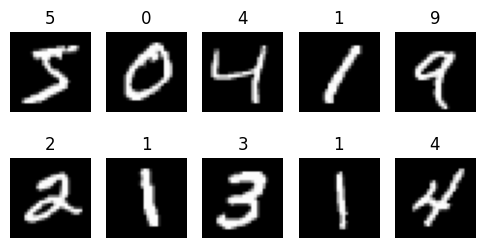

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

for i in range(10):
    plt.subplot(2, 5, i+1)   # 2 hàng, 5 cột
    plt.imshow(X_train[i], cmap='grey')
    plt.title(Y_train[i])
    plt.axis('off')

plt.show()

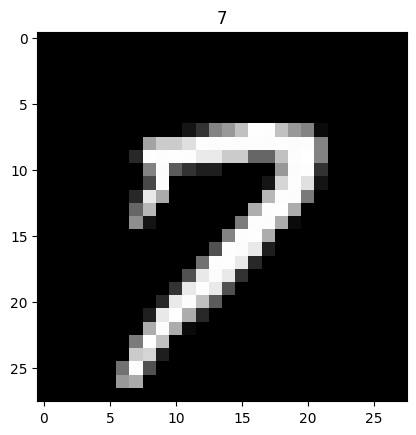

In [ ]:
index=599
plt.imshow(X_train[index], cmap='gray')
plt.title(Y_train[index])
plt.show()

In [ ]:
X_train = X_train.astype("float16")/255.0
X_test = X_test.astype("float16")/255.0
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

In [ ]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


In [ ]:
model= models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer= "adam",
    loss= "sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)
history = model.fit(
    X_train, Y_train,
    batch_size= 64,
    epochs= 10,
    validation_split= 0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8992 - loss: 0.3296 - val_accuracy: 0.9847 - val_loss: 0.0586
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9626 - loss: 0.1269 - val_accuracy: 0.9887 - val_loss: 0.0421
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9721 - loss: 0.0946 - val_accuracy: 0.9897 - val_loss: 0.0360
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9764 - loss: 0.0779 - val_accuracy: 0.9908 - val_loss: 0.0340
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9796 - loss: 0.0671 - val_accuracy: 0.9913 - val_loss: 0.0344
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.9828 - loss: 0.0567 - val_accuracy: 0.9902 - val_loss: 0.0379
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.9832 - loss: 0.0525 - val_accuracy: 0.9910 - val_loss: 0.0365
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9858 - loss: 0.0465 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9921 - loss: 0.0259
Test accuracy: 0.9921000003814697


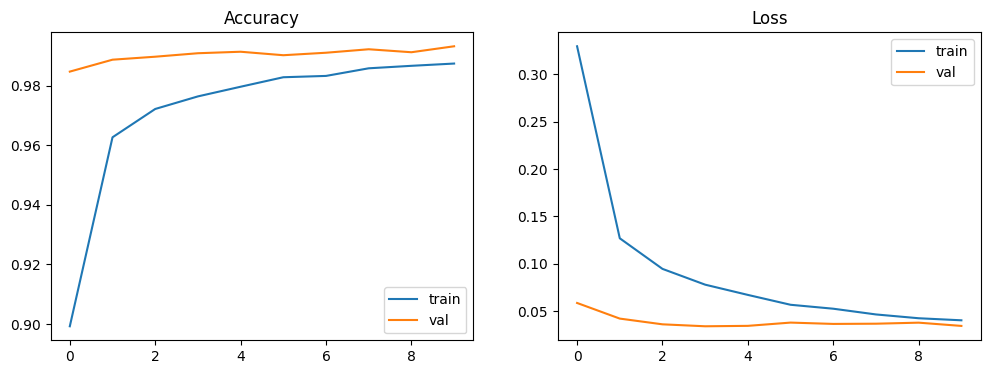

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


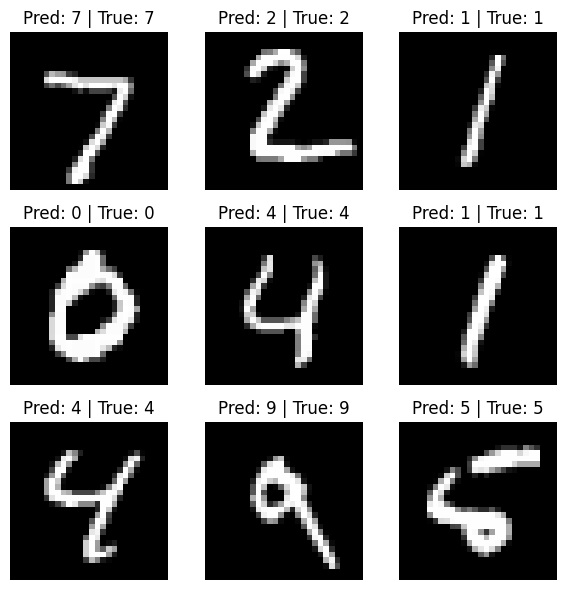

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.show()

preds = model.predict(X_test[:9])
fig, axes = plt.subplots(3,3, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].squeeze(), cmap='gray')
    ax.set_title(f"Pred: {np.argmax(preds[i])} | True: {Y_test[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()